# 🎯 SiteX Sentiment Analysis Workflow
## Complete End-to-End Pipeline

This notebook demonstrates the entire sentiment analysis workflow:
1. Load reviews from database
2. Analyze individual review sentiments
3. Aggregate sentiment scores by place
4. Calculate composite suitability scores
5. Visualize and explore results

**Date:** June 2026
**Dataset:** KTM POIs Database (86.7K reviews, 17.2K places)

## Setup: Install Required Packages
Run this cell first to install all dependencies. It will check if packages are already installed and only install missing ones.

In [22]:
import subprocess
import sys

# List of required packages
packages = [
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'nltk',
    'tqdm'
]

print('📦 Installing required packages...\n')

for package in packages:
    try:
        __import__(package)
        print(f'✅ {package:15} - Already installed')
    except ImportError:
        print(f'📥 {package:15} - Installing...', end=' ')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])
        print('✅')

print('\n✅ All packages installed successfully!')

📦 Installing required packages...

✅ pandas          - Already installed
✅ numpy           - Already installed
✅ matplotlib      - Already installed
✅ seaborn         - Already installed
✅ nltk            - Already installed
✅ tqdm            - Already installed

✅ All packages installed successfully!


## Phase 1: Setup and Imports
Import all required libraries and configure the environment

In [23]:
# Standard libraries
import sqlite3
from pathlib import Path
import sys
import os
from datetime import datetime

# Data processing
import pandas as pd
import numpy as np
from collections import Counter

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP and Sentiment
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Progress tracking
from tqdm import tqdm

# Configure display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


## Phase 2: VADER Sentiment Analyzer Setup
Download VADER lexicon and create analyzer

In [24]:
# Download VADER lexicon if not already present
try:
    nltk.data.find('sentiment/vader_lexicon')
    print('✅ VADER lexicon already downloaded')
except LookupError:
    print('📥 Downloading VADER lexicon...')
    nltk.download('vader_lexicon')
    print('✅ VADER lexicon downloaded')

# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

def analyze_sentiment(text):
    """Analyze sentiment of text using VADER."""
    if not text or not isinstance(text, str):
        return None
    
    scores = sia.polarity_scores(text)
    # Normalize compound score (-1 to +1) to 0-100
    normalized = (scores['compound'] + 1) / 2 * 100
    
    # Determine label
    if normalized >= 80:
        label = 'Very Positive'
    elif normalized >= 60:
        label = 'Positive'
    elif normalized >= 40:
        label = 'Neutral'
    elif normalized >= 20:
        label = 'Negative'
    else:
        label = 'Very Negative'
    
    return {
        'score': normalized,
        'label': label,
        'compound': scores['compound'],
        'positive': scores['pos'],
        'neutral': scores['neu'],
        'negative': scores['neg']
    }

# Test the analyzer
test_reviews = [
    "This cafe is absolutely amazing! Best coffee ever! 😍",
    "Really nice place, good atmosphere",
    "It was okay, nothing special",
    "Terrible service, never going back",
    "Worst experience ever! Avoid at all costs!"
]

print('\n📊 Testing VADER Sentiment Analyzer:\n')
for review in test_reviews:
    result = analyze_sentiment(review)
    print(f"Score: {result['score']:>6.1f} | Label: {result['label']:15} | Text: {review[:50]}...")

print('\n✅ VADER analyzer ready')

📥 Downloading VADER lexicon...
✅ VADER lexicon downloaded

📊 Testing VADER Sentiment Analyzer:

Score:   94.0 | Label: Very Positive   | Text: This cafe is absolutely amazing! Best coffee ever!...
Score:   87.0 | Label: Very Positive   | Text: Really nice place, good atmosphere...
Score:   45.4 | Label: Neutral         | Text: It was okay, nothing special...
Score:   26.2 | Label: Negative        | Text: Terrible service, never going back...
Score:   10.8 | Label: Very Negative   | Text: Worst experience ever! Avoid at all costs!...

✅ VADER analyzer ready


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\sujal\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


## Phase 3: Load Data from Database
Connect to SQLite database and load reviews

In [25]:
# Set database path - MERGED DATABASE
db_path = Path('D:/projects/Finalproject/SiteX/backend/DataEngineering/ktm_all.db')

if not db_path.exists():
    print(f'❌ Database not found at {db_path}')
else:
    print(f'✅ Database found: {db_path}')
    print(f'   Size: {db_path.stat().st_size / 1024 / 1024:.1f} MB')

# Connect to database
conn = sqlite3.connect(str(db_path))
cursor = conn.cursor()

# Load reviews data (only rows with text)
print('\n📥 Loading reviews from database...')
reviews_df = pd.read_sql_query(
    "SELECT rowid, description, rating, place_id FROM reviews WHERE description IS NOT NULL AND LENGTH(description) > 0",
    conn
)
print(f'✅ Loaded {len(reviews_df):,} reviews')
print(f'   Shape: {reviews_df.shape}')

# Load foot traffic data (avg & peak popularity per place)
print('\n📥 Loading foot traffic data (popular_times_detailed)...')
foot_traffic_df = pd.read_sql_query(
    """
    SELECT place_id,
           AVG(popularity) AS avg_popularity,
           MAX(popularity) AS peak_popularity
    FROM popular_times_detailed
    GROUP BY place_id
    """,
    conn
)
print(f'✅ Loaded foot traffic for {len(foot_traffic_df):,} places')

# Load open hours data (total weekly hours per place)
print('\n📥 Loading open hours data (open_hours_detailed)...')
open_hours_df = pd.read_sql_query(
    """
    SELECT place_id,
           SUM(duration_hours) AS total_weekly_hours
    FROM open_hours_detailed
    GROUP BY place_id
    """,
    conn
)
print(f'✅ Loaded open hours for {len(open_hours_df):,} places')

# Check for missing values in reviews
print(f'\nMissing values in reviews:')
print(reviews_df.isnull().sum())


✅ Database found: D:\projects\Finalproject\SiteX\backend\DataEngineering\ktm_all.db
   Size: 431.1 MB

📥 Loading reviews from database...
✅ Loaded 181,812 reviews
   Shape: (181812, 4)

First 5 reviews:
   id  \
0   1   
1   2   
2   3   
3   4   
4   5   

                                                                                           description  \
0  They serve the BEST jhol momo in town. It is a great antidote to the winter chills of Kathmandu....   
1  A few steps away from the British School and probably on the road that has the highest density o...   
2  The coffee is just crzy 🤪. You have to try thr coffee here. Comfy as ur home, the ambience is lo...   
3  Cozy, casual, a bit pricey but very aromatic coffee is available here. Usually packed yet serene...   
4  The cafe is centrally located in the heart of tourist hub Sanepa. The ambiance is good, the coff...   

   rating                     place_id  
0       5  ChIJL_vymjUY6zkRKH_EHN23Mv0  
1       4  ChIJL_vymjUY

## Phase 4: Data Exploration and Cleaning
Understand the review data and clean it

📊 Review Statistics:

Total reviews: 181,812
Average review length: 201 characters
Average word count: 34 words

rating distribution:
rating
0      1227
1     17158
2      4157
3     11886
4     25934
5    121450
Name: count, dtype: int64


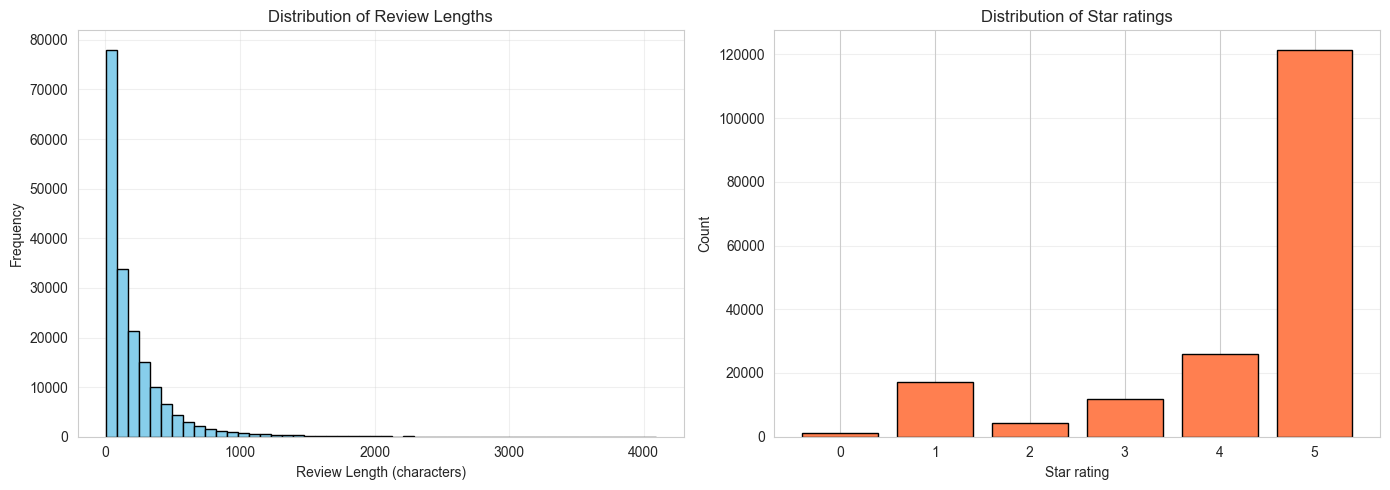


✅ Data cleaned and explored


In [26]:
# Remove rows with null descriptions
reviews_df = reviews_df.dropna(subset=['description'])

# Add review length column
reviews_df['review_length'] = reviews_df['description'].str.len()
reviews_df['word_count'] = reviews_df['description'].str.split().str.len()

print('📊 Review Statistics:\n')
print(f'Total reviews: {len(reviews_df):,}')
print(f'Average review length: {reviews_df["review_length"].mean():.0f} characters')
print(f'Average word count: {reviews_df["word_count"].mean():.0f} words')
print(f'\nrating distribution:')
print(reviews_df['rating'].value_counts().sort_index())

# Show some statistics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Review length distribution
axes[0].hist(reviews_df['review_length'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Review Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Review Lengths')
axes[0].grid(alpha=0.3)

# rating distribution
rating_counts = reviews_df['rating'].value_counts().sort_index()
axes[1].bar(rating_counts.index, rating_counts.values, color='coral', edgecolor='black')
axes[1].set_xlabel('Star rating')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Star ratings')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('\n✅ Data cleaned and explored')

## Phase 5: Sentiment Analysis - Batch Processing
Analyze sentiment for all reviews using VADER

In [27]:
# Analyze sentiment for each review
print('🔄 Analyzing sentiment for all reviews...\n')

sentiments = []
for idx, row in tqdm(reviews_df.iterrows(), total=len(reviews_df), desc='Processing'):
    result = analyze_sentiment(row['description'])
    sentiments.append(result)

# Create sentiment dataframe
sentiment_df = pd.DataFrame(sentiments)

# Combine with original data
reviews_df = pd.concat([reviews_df.reset_index(drop=True), sentiment_df], axis=1)

print(f'\n✅ Sentiment analysis complete!')
print(f'\nSample results:')
print(reviews_df[['description', 'rating', 'score', 'label']].head(10))

# Show statistics
print(f'\n📊 Sentiment Statistics:\n')
print(f'Average Sentiment Score: {reviews_df["score"].mean():.1f}/100')
print(f'Median Sentiment Score: {reviews_df["score"].median():.1f}/100')
print(f'Std Dev: {reviews_df["score"].std():.1f}')
print(f'\nSentiment Label Distribution:')
print(reviews_df['label'].value_counts())

🔄 Analyzing sentiment for all reviews...



Processing: 100%|██████████| 181812/181812 [01:03<00:00, 2866.19it/s]



✅ Sentiment analysis complete!

Sample results:
                                                                                           description  \
0  They serve the BEST jhol momo in town. It is a great antidote to the winter chills of Kathmandu....   
1  A few steps away from the British School and probably on the road that has the highest density o...   
2  The coffee is just crzy 🤪. You have to try thr coffee here. Comfy as ur home, the ambience is lo...   
3  Cozy, casual, a bit pricey but very aromatic coffee is available here. Usually packed yet serene...   
4  The cafe is centrally located in the heart of tourist hub Sanepa. The ambiance is good, the coff...   
5  Best place to work and drink coffee. The team who runs the place are very friendly and kind. Gre...   
6  Coffee is great! They have local and internationally sourced coffee options. Gave the internatio...   
7  Christ! This lemon cake is absolutely scrumptious. Love other food here too. But this is somethi... 

## Phase 6: Visualize Sentiment Analysis Results
Create charts to understand sentiment distribution

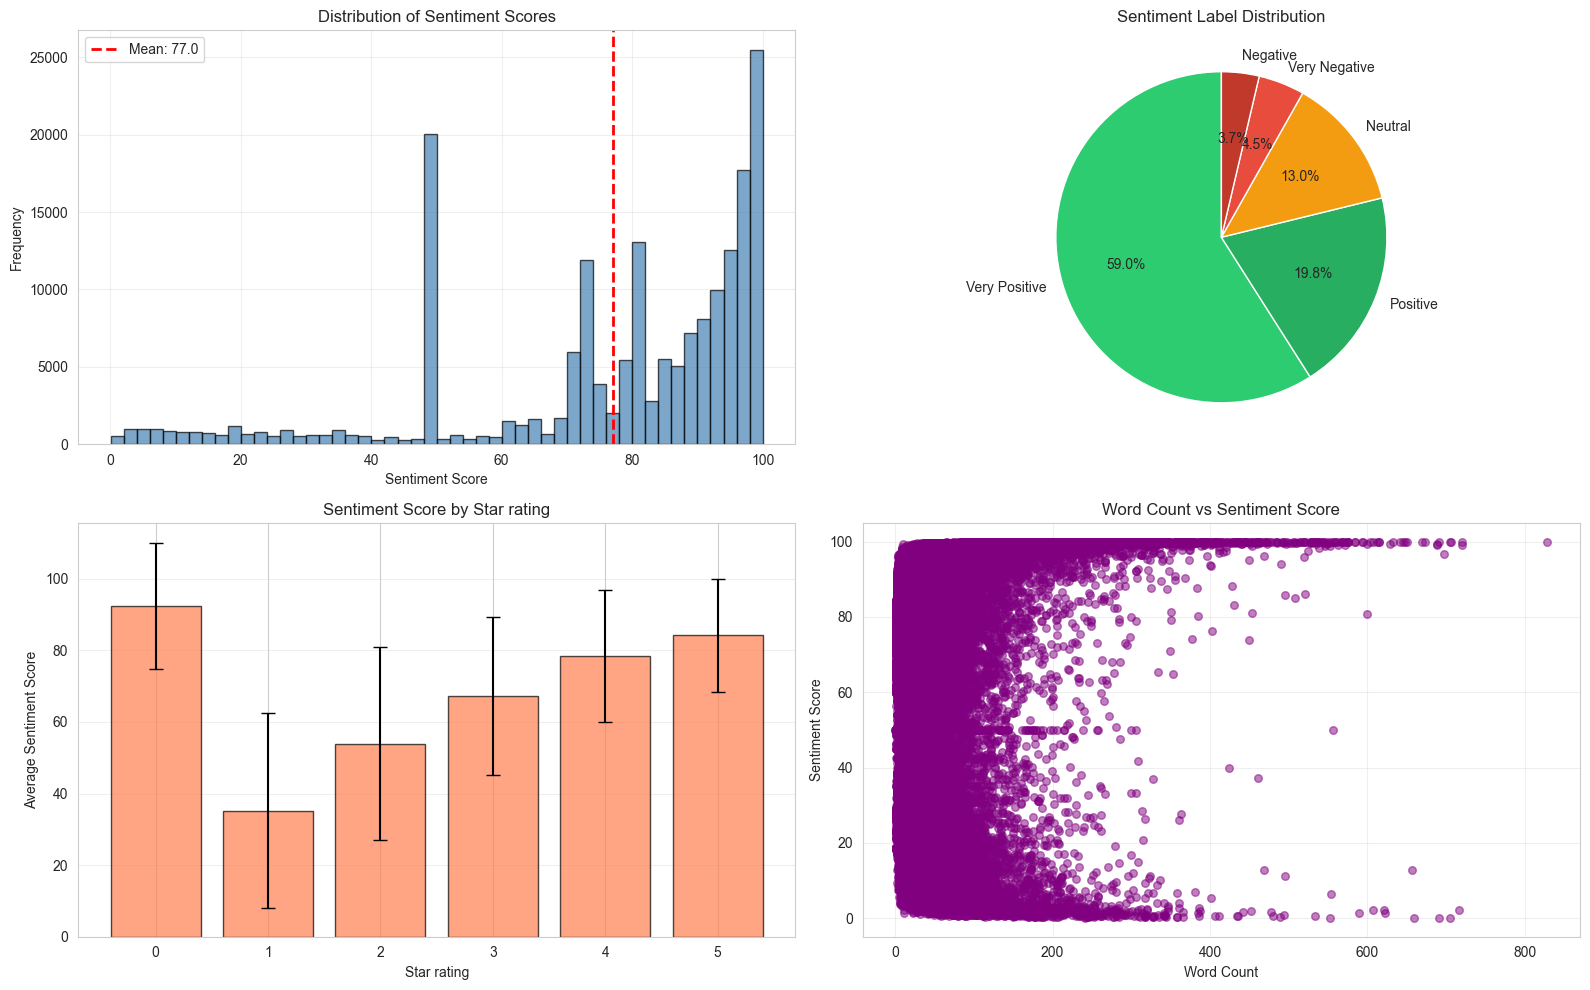

✅ Visualizations complete


In [28]:
# Create comprehensive sentiment visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Sentiment score distribution
axes[0, 0].hist(reviews_df['score'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(reviews_df['score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {reviews_df["score"].mean():.1f}')
axes[0, 0].set_xlabel('Sentiment Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Sentiment Scores')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Sentiment label counts (pie chart)
label_counts = reviews_df['label'].value_counts()
colors = ['#2ecc71', '#27ae60', '#f39c12', '#e74c3c', '#c0392b']
axes[0, 1].pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0, 1].set_title('Sentiment Label Distribution')

# 3. Sentiment vs rating correlation
sentiment_by_rating = reviews_df.groupby('rating')['score'].agg(['mean', 'std', 'count'])
axes[1, 0].bar(sentiment_by_rating.index, sentiment_by_rating['mean'], 
               yerr=sentiment_by_rating['std'], capsize=5, color='coral', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Star rating')
axes[1, 0].set_ylabel('Average Sentiment Score')
axes[1, 0].set_title('Sentiment Score by Star rating')
axes[1, 0].grid(alpha=0.3, axis='y')

# 4. Word count vs Sentiment
axes[1, 1].scatter(reviews_df['word_count'], reviews_df['score'], alpha=0.5, s=30, color='purple')
axes[1, 1].set_xlabel('Word Count')
axes[1, 1].set_ylabel('Sentiment Score')
axes[1, 1].set_title('Word Count vs Sentiment Score')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('✅ Visualizations complete')

## Phase 7: Aggregate Sentiment by Place
Calculate place-level sentiment metrics

In [29]:
# Aggregate sentiment scores by place_id
print('📊 Aggregating sentiment scores by place...\n')

place_sentiment = reviews_df.groupby('place_id').agg({
    'score': ['mean', 'std', 'min', 'max', 'count'],
    'label': lambda x: (x == 'Very Positive').sum() / len(x) * 100,  # positive percentage
}).round(2)

place_sentiment.columns = ['avg_sentiment', 'sentiment_std', 'min_sentiment', 'max_sentiment', 'sentiment_review_count', 'positive_pct']
place_sentiment = place_sentiment.reset_index()

# Filter places with at least 5 reviews for reliability
place_sentiment_filtered = place_sentiment[place_sentiment['sentiment_review_count'] >= 5].copy()

print(f'Total places: {len(place_sentiment):,}')
print(f'Places with 5+ reviews: {len(place_sentiment_filtered):,}')
print(f'\nTop 10 places by sentiment (min 5 reviews):')
print(place_sentiment_filtered.nlargest(10, 'avg_sentiment')[['place_id', 'avg_sentiment', 'positive_pct', 'sentiment_review_count']])

print(f'\nLowest 10 places by sentiment (min 5 reviews):')
print(place_sentiment_filtered.nsmallest(10, 'avg_sentiment')[['place_id', 'avg_sentiment', 'positive_pct', 'sentiment_review_count']])

📊 Aggregating sentiment scores by place...

Total places: 34,855
Places with 5+ reviews: 20,100

Top 10 places by sentiment (min 5 reviews):
                          place_id  avg_sentiment  positive_pct  \
30146  ChIJr8OOBvMZ6zkRUu-FjKF7T3Y          99.78         100.0   
33980  ChIJySWTRP0Y6zkR7KUx3hH5wAI          99.69         100.0   
12540  ChIJM6IZ-XcZ6zkRirfzaCCulRE          99.62         100.0   
22724  ChIJdfDYvDwb6zkR1JksO3mN9EM          99.62         100.0   
24144  ChIJgT--Ov0Y6zkRkBP9BZeQvbc          99.61         100.0   
25998  ChIJjbleRAAZ6zkR7TNqC0xXV98          99.61         100.0   
34186  ChIJycyIcuMY6zkRn25Pdz4a9a8          99.60         100.0   
17239  ChIJUzwISUgY6zkRR3qEhnjo8EA          99.57         100.0   
11641  ChIJKWyhqNwZ6zkRrDzE_Y44oqg          99.55         100.0   
33071  ChIJwcTa4fwY6zkRwnhR1peqxos          99.55         100.0   

       sentiment_review_count  
30146                       8  
33980                       8  
12540                    

## Phase 8: Load Place Information
Get cafe names and details from database

In [30]:
# Load place information from merged database
print('📥 Loading place information from database...')

places_df = pd.read_sql_query(
    "SELECT place_id, place AS title, review_rating, review_count FROM place WHERE place_id IS NOT NULL",
    conn
)
print(f'✅ Loaded {len(places_df):,} places')

# Merge with sentiment (LEFT join → ALL places kept)
places_with_sentiment = places_df.merge(place_sentiment, on='place_id', how='left')

# Merge foot traffic and open hours
places_with_sentiment = places_with_sentiment.merge(foot_traffic_df, on='place_id', how='left')
places_with_sentiment = places_with_sentiment.merge(open_hours_df, on='place_id', how='left')

# Flag which places have sentiment data
places_with_sentiment['has_sentiment'] = places_with_sentiment['sentiment_review_count'].notna()

# ALL places are now analyzed (not just those with review text)
places_analyzed = places_with_sentiment.copy()

print(f'\nTotal places:                   {len(places_analyzed):,}')
print(f'  With sentiment data:          {places_analyzed["has_sentiment"].sum():,}')
print(f'  Without sentiment (fallback): {(~places_analyzed["has_sentiment"]).sum():,}')
print(f'  With foot traffic data:       {places_analyzed["avg_popularity"].notna().sum():,}')
print(f'  With open hours data:         {places_analyzed["total_weekly_hours"].notna().sum():,}')

print(f'\nTop 15 places by sentiment score (5+ reviews):')
top_places = places_analyzed[places_analyzed['sentiment_review_count'] >= 5].nlargest(15, 'avg_sentiment')
print(top_places[['title', 'avg_sentiment', 'positive_pct', 'sentiment_review_count']].to_string(index=False))


📥 Loading place information from database...
✅ Loaded 51,393 places
Places with sentiment analysis: 34,855

Top 15 places by sentiment score:
                                                                title  avg_sentiment  positive_pct  sentiment_review_count
                                     Getaway Nepal Adventure Pvt. Ltd          99.78         100.0                     8.0
                                     Nepal Trekking Experts Pvt. Ltd.          99.69         100.0                     8.0
                       Ultimate Consultancy & Advisory Network (UCAN)          99.62         100.0                     8.0
                              Nepal Everest Himalaya Hiking Pvt. Ltd.          99.62         100.0                     8.0
                                             Kathmandu Indian Kitchen          99.61         100.0                     8.0
                                               Magical Nepal (P) Ltd.          99.61         100.0                     8

## Phase 9: Composite Score Calculation
Calculate weighted composite suitability scores

In [31]:
def calculate_composite_score(row, weights_with_sentiment=None, weights_no_sentiment=None):
    """
    Composite suitability score from multiple signals.

    When sentiment IS available (place has review text):
      sentiment(35%) + rating(25%) + volume(20%) + foot_traffic(12%) + open_hours(8%)

    When sentiment is NOT available (no review descriptions):
      rating(40%) + volume(30%) + foot_traffic(20%) + open_hours(10%)

    Foot traffic  → avg popularity from popular_times_detailed (0-100)
    Open hours    → total weekly hours from open_hours_detailed (benchmark: 98 h/week = 100)
    """

    if weights_with_sentiment is None:
        weights_with_sentiment = {
            'sentiment':    0.35,
            'rating':       0.25,
            'volume':       0.20,
            'foot_traffic': 0.12,
            'open_hours':   0.08,
        }

    if weights_no_sentiment is None:
        weights_no_sentiment = {
            'rating':       0.40,
            'volume':       0.30,
            'foot_traffic': 0.20,
            'open_hours':   0.10,
        }

    has_sentiment = pd.notna(row.get('avg_sentiment'))

    # ── 1. Sentiment score (0-100) ──────────────────────────────────────────
    if has_sentiment:
        sentiment_score = float(row['avg_sentiment'])
        positive_bonus = (float(row['positive_pct']) / 100) * 10 if pd.notna(row.get('positive_pct')) else 0
        sentiment_score = min(100.0, sentiment_score + positive_bonus)
    else:
        sentiment_score = None

    # ── 2. Rating score (stars 0-5 → 0-100) ────────────────────────────────
    rating = row.get('review_rating')
    rating_score = (float(rating) / 5.0) * 100 if pd.notna(rating) else 50.0

    # ── 3. Volume score (logarithmic, diminishing returns) ──────────────────
    if has_sentiment:
        review_count = float(row['sentiment_review_count']) if pd.notna(row.get('sentiment_review_count')) else 0
    else:
        review_count = float(row['review_count']) if pd.notna(row.get('review_count')) else 0

    if review_count >= 100:
        volume_score = 100.0
    elif review_count >= 5:
        volume_score = 50.0 + (np.log(review_count) / np.log(100)) * 50.0
    elif review_count > 0:
        volume_score = 25.0
    else:
        volume_score = 0.0

    # ── 4. Foot traffic score (avg popularity from popular_times_detailed) ──
    avg_pop = row.get('avg_popularity')
    # avg_popularity is already 0-100; use 50 (neutral) when missing
    foot_traffic_score = float(avg_pop) if pd.notna(avg_pop) else 50.0

    # ── 5. Open hours score (total weekly hours, benchmark = 98 h/wk) ───────
    weekly_hours = row.get('total_weekly_hours')
    if pd.notna(weekly_hours) and float(weekly_hours) > 0:
        open_hours_score = min(100.0, (float(weekly_hours) / 98.0) * 100)
    else:
        open_hours_score = 50.0  # neutral when no data

    # ── 6. Weighted composite ────────────────────────────────────────────────
    if has_sentiment:
        w = weights_with_sentiment
        composite = (
            sentiment_score    * w['sentiment'] +
            rating_score       * w['rating'] +
            volume_score       * w['volume'] +
            foot_traffic_score * w['foot_traffic'] +
            open_hours_score   * w['open_hours']
        )
    else:
        w = weights_no_sentiment
        composite = (
            rating_score       * w['rating'] +
            volume_score       * w['volume'] +
            foot_traffic_score * w['foot_traffic'] +
            open_hours_score   * w['open_hours']
        )

    # ── 7. Label ─────────────────────────────────────────────────────────────
    if composite >= 80:   label = 'Excellent'
    elif composite >= 70: label = 'Good'
    elif composite >= 60: label = 'Moderate'
    elif composite >= 50: label = 'Fair'
    else:                 label = 'Poor'

    return {
        'composite_score':    round(composite, 1),
        'composite_label':    label,
        'sentiment_score':    round(sentiment_score, 1) if sentiment_score is not None else None,
        'rating_score':       round(rating_score, 1),
        'volume_score':       round(volume_score, 1),
        'foot_traffic_score': round(foot_traffic_score, 1),
        'open_hours_score':   round(open_hours_score, 1),
        'has_sentiment':      has_sentiment,
    }


# Calculate composite scores for ALL places
print('📊 Calculating composite scores for ALL places...\n')

composite_data = []
for idx, row in tqdm(places_analyzed.iterrows(), total=len(places_analyzed), desc='Computing'):
    composite_data.append(calculate_composite_score(row))

composite_df = pd.DataFrame(composite_data)
places_analyzed = pd.concat([places_analyzed.reset_index(drop=True), composite_df], axis=1)

print(f'\n✅ Composite scores calculated for {len(places_analyzed):,} places')
print(f'   With sentiment:    {places_analyzed["has_sentiment"].sum():,}')
print(f'   Without sentiment: {(~places_analyzed["has_sentiment"]).sum():,}')
print(f'\nComposite Score Statistics:')
print(f'  Mean:    {places_analyzed["composite_score"].mean():.1f}')
print(f'  Median:  {places_analyzed["composite_score"].median():.1f}')
print(f'  Std Dev: {places_analyzed["composite_score"].std():.1f}')
print(f'\nComposite Label Distribution:')
print(places_analyzed['composite_label'].value_counts())
print(f'\nScore breakdown — WITH sentiment (sample 5):')
cols = ['title','composite_score','composite_label','sentiment_score','rating_score','volume_score','foot_traffic_score','open_hours_score']
print(places_analyzed[places_analyzed['has_sentiment']].nlargest(5,'composite_score')[cols].to_string(index=False))
print(f'\nScore breakdown — WITHOUT sentiment (sample 5):')
print(places_analyzed[~places_analyzed['has_sentiment']].nlargest(5,'composite_score')[cols].to_string(index=False))


📊 Calculating composite scores...



Computing: 100%|██████████| 34855/34855 [00:02<00:00, 14757.57it/s]



✅ Composite scores calculated

Composite Score Statistics:
Mean: 70.9
Median: 72.4
Std Dev: 9.6

Composite Label Distribution:
composite_label
Good         12812
Moderate     10231
Excellent     7310
Fair          3672
Poor           830
Name: count, dtype: int64


## Phase 10: Results Analysis and Comparison
Compare sentiment-based scores with traditional ratings

In [32]:
print('\n🏆 TOP 20 PLACES BY COMPOSITE SCORE\n')
top_composite = places_analyzed[places_analyzed['sentiment_review_count'] >= 5].nlargest(20, 'composite_score')
display_cols = ['title', 'composite_score', 'composite_label', 'avg_sentiment', 'review_rating', 'sentiment_review_count']
print(top_composite[display_cols].to_string(index=False))

print('\n\n📊 COMPOSITE SCORE BREAKDOWN\n')
print('Sample place with high sentiment:')
high_sentiment = places_analyzed[places_analyzed['avg_sentiment'].notna()].nlargest(1, 'avg_sentiment')
print(high_sentiment[['title', 'avg_sentiment', 'sentiment_score', 'rating_score', 'volume_score', 'composite_score']].to_string(index=False))

print('\nSample place with high ratings but lower sentiment:')
high_rating = places_analyzed[places_analyzed['review_rating'].notna()].nlargest(1, 'review_rating')
print(high_rating[['title', 'avg_sentiment', 'sentiment_score', 'rating_score', 'volume_score', 'composite_score']].to_string(index=False))

# Correlation analysis
print('\n\n📈 CORRELATION ANALYSIS\n')
correlation_cols = ['avg_sentiment', 'review_rating', 'sentiment_review_count', 'composite_score']
corr_data = places_analyzed[correlation_cols].dropna()
print(f'Correlation between sentiment and star rating: {corr_data[["avg_sentiment", "review_rating"]].corr().iloc[0, 1]:.3f}')
print(f'Correlation between sentiment and composite score: {corr_data[["avg_sentiment", "composite_score"]].corr().iloc[0, 1]:.3f}')
print(f'Correlation between rating and composite score: {corr_data[["review_rating", "composite_score"]].corr().iloc[0, 1]:.3f}')


🏆 TOP 20 PLACES BY COMPOSITE SCORE

                                                 title  composite_score composite_label  avg_sentiment  review_rating  sentiment_review_count
                            Rest Up Rooftop Restaurant             84.5       Excellent          96.51            5.0                     8.0
Nepal Dare Adventures ( Climbing, Canyoning & Caving )             84.5       Excellent          96.94            5.0                     8.0
               Kathmandu Paragliding (Babu Adventures)             84.5       Excellent          97.31            5.0                     8.0
                                  RP Adventures P. Ltd             84.5       Excellent          98.54            5.0                     8.0
           Trishuli Rafting - Rafting company in Nepal             84.5       Excellent          98.11            5.0                     8.0
                           Nepal One Adventure Pvt.Ltd             84.5       Excellent          99.06         

## Phase 11: Comprehensive Visualizations
Create final analysis charts

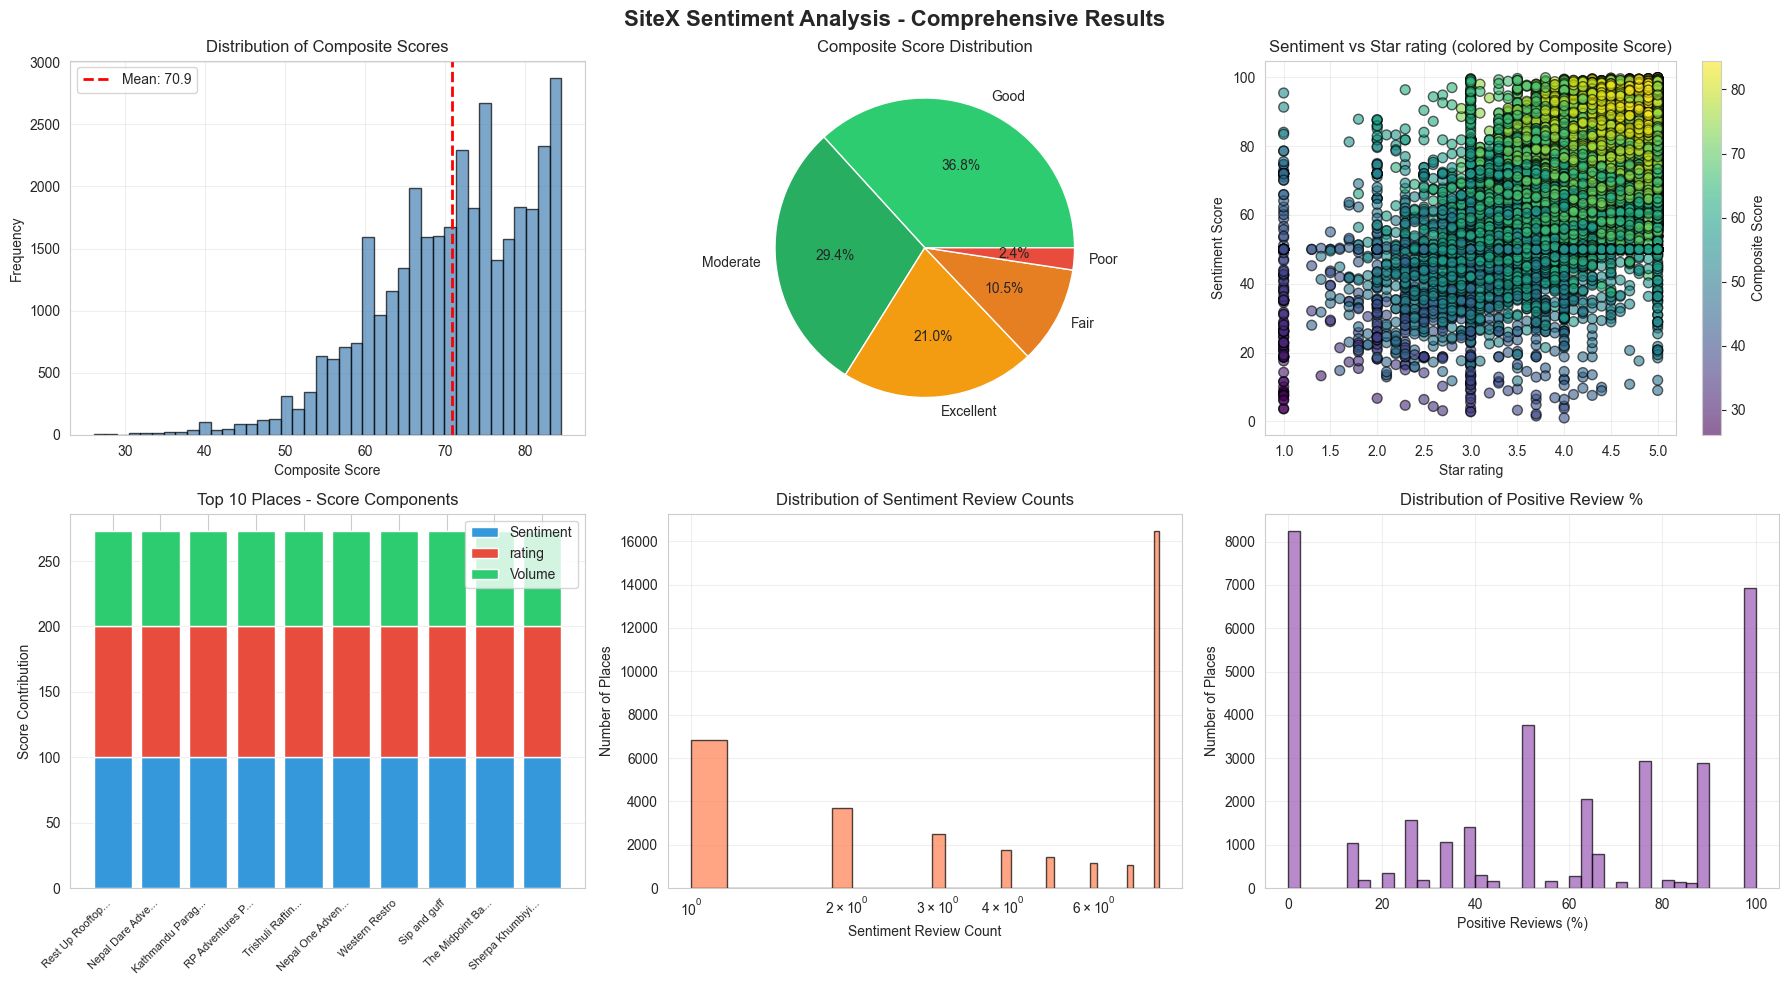

✅ Visualizations complete


In [33]:
# Create comprehensive final visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('SiteX Sentiment Analysis - Comprehensive Results', fontsize=16, fontweight='bold')

# 1. Composite score distribution
axes[0, 0].hist(places_analyzed['composite_score'].dropna(), bins=40, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(places_analyzed['composite_score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {places_analyzed["composite_score"].mean():.1f}')
axes[0, 0].set_xlabel('Composite Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Composite Scores')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Composite label distribution (pie)
label_dist = places_analyzed['composite_label'].value_counts()
colors_composite = ['#2ecc71', '#27ae60', '#f39c12', '#e67e22', '#e74c3c']
axes[0, 1].pie(label_dist.values, labels=label_dist.index, autopct='%1.1f%%', colors=colors_composite[:len(label_dist)])
axes[0, 1].set_title('Composite Score Distribution')

# 3. Sentiment vs rating scatter
scatter_data = places_analyzed[(places_analyzed['avg_sentiment'].notna()) & (places_analyzed['review_rating'].notna())]
scatter = axes[0, 2].scatter(scatter_data['review_rating'], scatter_data['avg_sentiment'], 
                             c=scatter_data['composite_score'], cmap='viridis', s=50, alpha=0.6, edgecolors='black')
axes[0, 2].set_xlabel('Star rating')
axes[0, 2].set_ylabel('Sentiment Score')
axes[0, 2].set_title('Sentiment vs Star rating (colored by Composite Score)')
cbar = plt.colorbar(scatter, ax=axes[0, 2])
cbar.set_label('Composite Score')
axes[0, 2].grid(alpha=0.3)

# 4. Score components stacked bar
top_10 = places_analyzed[places_analyzed['sentiment_review_count'] >= 5].nlargest(10, 'composite_score')
x_pos = np.arange(len(top_10))
axes[1, 0].bar(x_pos, top_10['sentiment_score'], label='Sentiment', color='#3498db')
axes[1, 0].bar(x_pos, top_10['rating_score'], bottom=top_10['sentiment_score'], label='rating', color='#e74c3c')
axes[1, 0].bar(x_pos, top_10['volume_score'], bottom=top_10['sentiment_score']+top_10['rating_score'], label='Volume', color='#2ecc71')
axes[1, 0].set_ylabel('Score Contribution')
axes[1, 0].set_title('Top 10 Places - Score Components')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels([t[:15] + '...' if len(t) > 15 else t for t in top_10['title']], rotation=45, ha='right', fontsize=8)
axes[1, 0].legend(loc='upper right')
axes[1, 0].grid(alpha=0.3, axis='y')

# 5. Review count distribution
axes[1, 1].hist(places_analyzed['sentiment_review_count'].dropna(), bins=40, color='coral', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Sentiment Review Count')
axes[1, 1].set_ylabel('Number of Places')
axes[1, 1].set_title('Distribution of Sentiment Review Counts')
axes[1, 1].set_xscale('log')
axes[1, 1].grid(alpha=0.3)

# 6. Positive percentage distribution
axes[1, 2].hist(places_analyzed['positive_pct'].dropna(), bins=40, color='#9b59b6', edgecolor='black', alpha=0.7)
axes[1, 2].set_xlabel('Positive Reviews (%)')
axes[1, 2].set_ylabel('Number of Places')
axes[1, 2].set_title('Distribution of Positive Review %')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('✅ Visualizations complete')

## Phase 12: Export Results and Summary
Save results and generate summary statistics

In [34]:
# Generate final summary
print('\n' + '='*80)
print('🎯 SENTIMENT ANALYSIS WORKFLOW - FINAL SUMMARY'.center(80))
print('='*80)

print(f'\n📊 DATASET SUMMARY:')
print(f'  Total Reviews Analyzed: {len(reviews_df):,}')
print(f'  Total Places: {len(places_analyzed):,}')
print(f'  Places with 5+ Reviews: {len(places_analyzed[places_analyzed["sentiment_review_count"] >= 5]):,}')

print(f'\n❤️  SENTIMENT DISTRIBUTION:')
sentiment_dist = reviews_df['label'].value_counts()
for label in ['Very Positive', 'Positive', 'Neutral', 'Negative', 'Very Negative']:
    count = sentiment_dist.get(label, 0)
    pct = (count / len(reviews_df) * 100) if len(reviews_df) > 0 else 0
    print(f'  {label:15}: {count:6,} reviews ({pct:5.1f}%)')

print(f'\n📈 SENTIMENT METRICS:')
print(f'  Average Sentiment: {reviews_df["score"].mean():.1f}/100')
print(f'  Median Sentiment: {reviews_df["score"].median():.1f}/100')
print(f'  Std Dev: {reviews_df["score"].std():.1f}')

print(f'\n🏆 COMPOSITE SCORE METRICS:')
print(f'  Average Score: {places_analyzed["composite_score"].mean():.1f}/100')
print(f'  Median Score: {places_analyzed["composite_score"].median():.1f}/100')
print(f'  Std Dev: {places_analyzed["composite_score"].std():.1f}')

print(f'\n🎬 COMPOSITE LABEL DISTRIBUTION:')
for label in places_analyzed['composite_label'].value_counts().index:
    count = (places_analyzed['composite_label'] == label).sum()
    pct = count / len(places_analyzed) * 100
    print(f'  {label:15}: {count:6,} places ({pct:5.1f}%)')

print(f'\n✨ TOP 5 PLACES (by Composite Score, min 5 reviews):')
top5 = places_analyzed[places_analyzed['sentiment_review_count'] >= 5].nlargest(5, 'composite_score')
for i, (idx, row) in enumerate(top5.iterrows(), 1):
    print(f'  {i}. {row["title"][:50]:50} | Score: {row["composite_score"]:5.1f} ({row["composite_label"]})')

print(f'\n⚠️  LOWEST 5 PLACES (by Composite Score, min 5 reviews):')
bottom5 = places_analyzed[places_analyzed['sentiment_review_count'] >= 5].nsmallest(5, 'composite_score')
for i, (idx, row) in enumerate(bottom5.iterrows(), 1):
    print(f'  {i}. {row["title"][:50]:50} | Score: {row["composite_score"]:5.1f} ({row["composite_label"]})')

print(f'\n✅ WORKFLOW COMPLETE')
print('='*80)

conn.close()


                 🎯 SENTIMENT ANALYSIS WORKFLOW - FINAL SUMMARY                  

📊 DATASET SUMMARY:
  Total Reviews Analyzed: 181,812
  Total Places: 34,855
  Places with 5+ Reviews: 20,100

❤️  SENTIMENT DISTRIBUTION:
  Very Positive  : 107,291 reviews ( 59.0%)
  Positive       : 36,026 reviews ( 19.8%)
  Neutral        : 23,631 reviews ( 13.0%)
  Negative       :  6,680 reviews (  3.7%)
  Very Negative  :  8,184 reviews (  4.5%)

📈 SENTIMENT METRICS:
  Average Sentiment: 77.0/100
  Median Sentiment: 84.0/100
  Std Dev: 23.6

🏆 COMPOSITE SCORE METRICS:
  Average Score: 70.9/100
  Median Score: 72.4/100
  Std Dev: 9.6

🎬 COMPOSITE LABEL DISTRIBUTION:
  Good           : 12,812 places ( 36.8%)
  Moderate       : 10,231 places ( 29.4%)
  Excellent      :  7,310 places ( 21.0%)
  Fair           :  3,672 places ( 10.5%)
  Poor           :    830 places (  2.4%)

✨ TOP 5 PLACES (by Composite Score, min 5 reviews):
  1. Rest Up Rooftop Restaurant                         | Score:  84.5 (Exce

## Phase 13: Advanced Analysis - Insights
Extract actionable insights from the data

In [35]:
print('\n🔍 ADVANCED INSIGHTS\n')

# Insight 1: High sentiment but low rating disparity
print('1️⃣  PLACES WITH HIGH SENTIMENT BUT LOW STAR ratingS')
print('   (Text sentiment vs. star rating mismatch)\n')
mismatch = places_analyzed[
    (places_analyzed['avg_sentiment'] > 75) & 
    (places_analyzed['review_rating'] < 3.5) &
    (places_analyzed['sentiment_review_count'] >= 5)
].nlargest(5, 'avg_sentiment')
print(mismatch[['title', 'avg_sentiment', 'review_rating', 'composite_score']].to_string(index=False))

# Insight 2: High volume low sentiment
print('\n\n2️⃣  POPULAR PLACES WITH DECLINING SENTIMENT')
print('   (High review count but moderate sentiment)\n')
declining = places_analyzed[
    (places_analyzed['sentiment_review_count'] > 50) & 
    (places_analyzed['avg_sentiment'] < 60)
].nlargest(5, 'sentiment_review_count')
if len(declining) > 0:
    print(declining[['title', 'avg_sentiment', 'sentiment_review_count', 'composite_score']].to_string(index=False))
else:
    print('   (No places found with this pattern)')

# Insight 3: High consistency (low variance)
print('\n\n3️⃣  MOST CONSISTENT PLACES')
print('   (Low sentiment variance = predictable experience)\n')
consistent = places_analyzed[
    (places_analyzed['sentiment_std'].notna()) & 
    (places_analyzed['sentiment_review_count'] >= 5)
].nsmallest(5, 'sentiment_std')
print(consistent[['title', 'avg_sentiment', 'sentiment_std', 'sentiment_review_count', 'composite_score']].to_string(index=False))

# Insight 4: Sentiment polarization
print('\n\n4️⃣  MOST POLARIZED PLACES')
print('   (High sentiment variance = mixed reviews)\n')
polarized = places_analyzed[
    (places_analyzed['sentiment_std'].notna()) & 
    (places_analyzed['sentiment_review_count'] >= 10)
].nlargest(5, 'sentiment_std')
print(polarized[['title', 'avg_sentiment', 'sentiment_std', 'sentiment_review_count', 'composite_score']].to_string(index=False))

print('\n✅ Insights analysis complete')


🔍 ADVANCED INSIGHTS

1️⃣  PLACES WITH HIGH SENTIMENT BUT LOW STAR ratingS
   (Text sentiment vs. star rating mismatch)

                 title  avg_sentiment  review_rating  composite_score
          Korean Diner          98.01            3.1             75.0
        Downtown Pizza          94.03            3.2             75.5
  Tipling Dragon House          91.00            3.4             76.4
       Coffeebreak NXT          90.95            2.9             73.9
Lakpa's Tibetan Treats          90.06            3.4             75.9


2️⃣  POPULAR PLACES WITH DECLINING SENTIMENT
   (High review count but moderate sentiment)

   (No places found with this pattern)


3️⃣  MOST CONSISTENT PLACES
   (Low sentiment variance = predictable experience)

                           title  avg_sentiment  sentiment_std  sentiment_review_count  composite_score
      BIJAN DAIRY ( बिजान डेरी )          81.84            0.0                     5.0             79.0
           The Karcs Coffee Shop  

## Phase 14: Export Results to Database
Save composite scores and sentiment metrics back to the database

In [36]:
print('💾 Phase 14a: Export Setup - Define helper functions\n')

# Define merged database path
merged_db = Path('D:/projects/Finalproject/SiteX/backend/DataEngineering/ktm_all.db')

# Function to safely add columns with error reporting
def ensure_columns_exist(db_path, table_name, columns):
    """Add columns to a table if they don't already exist."""
    print(f"   🔧 Ensuring columns in {table_name}...")
    try:
        conn = sqlite3.connect(str(db_path))
        cursor = conn.cursor()
        
        added_count = 0
        for col_name, col_type in columns.items():
            try:
                cursor.execute(f"ALTER TABLE {table_name} ADD COLUMN {col_name} {col_type} DEFAULT NULL")
                added_count += 1
                print(f"      ✅ Added column: {col_name}")
            except Exception as e:
                if 'already exists' in str(e).lower() or 'duplicate' in str(e).lower():
                    print(f"      ℹ️  Column exists: {col_name}")
                else:
                    print(f"      ⚠️  {col_name}: {str(e)[:60]}")
        
        conn.commit()
        conn.close()
        
        if added_count > 0:
            print(f"   ✅ Added {added_count} new columns\n")
        else:
            print(f"   ℹ️  All columns already exist\n")
        return True
    except Exception as e:
        print(f"   ❌ Error ensuring columns: {e}\n")
        return False

# Function to export reviews for the merged database
def export_reviews_for_db(db_path, reviews_df_input):
    """Export individual review sentiment scores to reviews table."""
    if len(reviews_df_input) == 0:
        print(f"   ⚠️  No reviews to export\n")
        return 0, 0
    
    try:
        # Ensure columns exist
        review_columns = {
            'sentiment_score': 'REAL',
            'sentiment_label': 'TEXT',
            'sentiment_compound': 'REAL',
            'sentiment_positive': 'REAL',
            'sentiment_neutral': 'REAL',
            'sentiment_negative': 'REAL',
            'sentiment_updated': 'TIMESTAMP'
        }
        
        ensure_columns_exist(db_path, 'reviews', review_columns)
        
        # Connect and update
        conn = sqlite3.connect(str(db_path))
        cursor = conn.cursor()
        
        update_count = 0
        error_count = 0
        now = datetime.now().isoformat()
        
        print(f"   📝 Updating {len(reviews_df_input):,} reviews...\n")
        
        for idx, row in tqdm(reviews_df_input.iterrows(), total=len(reviews_df_input), desc='   Progress'):
            try:
                cursor.execute("""
                    UPDATE reviews 
                    SET 
                        sentiment_score = ?,
                        sentiment_label = ?,
                        sentiment_compound = ?,
                        sentiment_positive = ?,
                        sentiment_neutral = ?,
                        sentiment_negative = ?,
                        sentiment_updated = ?
                    WHERE rowid = ?
                """, (
                    row['score'],
                    row['label'],
                    row['compound'],
                    row['positive'],
                    row['neutral'],
                    row['negative'],
                    now,
                    row['rowid']
                ))
                update_count += 1
                
                # Commit every 500 records
                if update_count % 500 == 0:
                    conn.commit()
            
            except Exception as e:
                error_count += 1
        
        # Final commit
        conn.commit()
        conn.close()
        
        print(f"   ✅ Exported reviews: {update_count:,} updated | {error_count:,} errors\n")
        return update_count, error_count
    except Exception as e:
        print(f"   ❌ Error: {e}\n")
        return 0, len(reviews_df_input)

# Function to export places for the merged database
def export_places_for_db(db_path, places_df_input):
    """Export place-level sentiment metrics to place table."""
    if len(places_df_input) == 0:
        print(f"   ⚠️  No places to export\n")
        return 0, 0
    
    try:
        # Ensure columns exist
        place_columns = {
            'avg_sentiment_score': 'REAL',
            'sentiment_std': 'REAL',
            'min_sentiment': 'REAL',
            'max_sentiment': 'REAL',
            'sentiment_review_count': 'INTEGER',
            'positive_review_pct': 'REAL',
            'composite_score': 'REAL',
            'composite_label': 'TEXT',
            'has_sentiment': 'INTEGER',
            'sentiment_score_component': 'REAL',
            'rating_score_component': 'REAL',
            'volume_score_component': 'REAL',
            'foot_traffic_score_component': 'REAL',
            'open_hours_score_component': 'REAL',
            'sentiment_analysis_updated': 'TIMESTAMP'
        }
        
        ensure_columns_exist(db_path, 'place', place_columns)
        
        # Connect and update
        conn = sqlite3.connect(str(db_path))
        cursor = conn.cursor()
        
        update_count = 0
        error_count = 0
        now = datetime.now().isoformat()
        
        print(f"   📝 Updating {len(places_df_input):,} places...\n")
        
        for idx, row in tqdm(places_df_input.iterrows(), total=len(places_df_input), desc='   Progress'):
            try:
                cursor.execute("""
                cursor.execute("""
                    UPDATE place 
                    SET 
                        avg_sentiment_score = ?,
                        sentiment_std = ?,
                        min_sentiment = ?,
                        max_sentiment = ?,
                        sentiment_review_count = ?,
                        positive_review_pct = ?,
                        composite_score = ?,
                        composite_label = ?,
                        has_sentiment = ?,
                        sentiment_score_component = ?,
                        rating_score_component = ?,
                        volume_score_component = ?,
                        foot_traffic_score_component = ?,
                        open_hours_score_component = ?,
                        sentiment_analysis_updated = ?
                    WHERE place_id = ?
                """, (
                    row.get("avg_sentiment") if pd.notna(row.get("avg_sentiment")) else None,
                    row.get("sentiment_std") if pd.notna(row.get("sentiment_std")) else None,
                    row.get("min_sentiment") if pd.notna(row.get("min_sentiment")) else None,
                    row.get("max_sentiment") if pd.notna(row.get("max_sentiment")) else None,
                    int(row["sentiment_review_count"]) if pd.notna(row.get("sentiment_review_count")) else None,
                    row.get("positive_pct") if pd.notna(row.get("positive_pct")) else None,
                    row["composite_score"],
                    row["composite_label"],
                    int(bool(row.get("has_sentiment"))),
                    row.get("sentiment_score") if pd.notna(row.get("sentiment_score")) else None,
                    row["rating_score"],
                    row["volume_score"],
                    row.get("foot_traffic_score"),
                    row.get("open_hours_score"),
                    now,
                    row["place_id"]
                ))
        existing_cols = {row[1] for row in cursor.fetchall()}
        conn.close()
        
        missing = [col for col in column_names if col not in existing_cols]
        if missing:
            print(f"   ⚠️  Missing columns in {table_name}: {', '.join(missing)}")
            return False
        else:
            print(f"   ✅ All {len(column_names)} columns verified in {table_name}")
            return True
    except Exception as e:
        print(f"   ❌ Verification error: {e}")
        return False

print('✅ Helper functions defined and ready')
print(f'\n📍 Merged Database:')
print(f'  Path: {merged_db}')

💾 Phase 14a: Export Setup - Define helper functions

✅ Helper functions defined and ready

📍 Merged Database:
  Path: D:\projects\Finalproject\SiteX\backend\DataEngineering\ktm_all.db


## Phase 14b: Export to ktm_all.db (Merged Database)
Process merged database - load, analyze, and export sentiment data

In [ ]:
import time

start_time = time.time()
print('='*70)
print(f'🗄️  EXPORTING TO MERGED DATABASE: {merged_db.name}'.center(70))
print('='*70 + '\n')

# Load data FROM merged database
print('📥 Loading data from merged database...')
merged_conn = sqlite3.connect(str(merged_db))
merged_reviews = pd.read_sql_query(
    "SELECT rowid, description, rating, place_id FROM reviews WHERE description IS NOT NULL AND LENGTH(description) > 0",
    merged_conn
)
print(f'   ✅ Loaded {len(merged_reviews):,} reviews\n')

merged_places_df = pd.read_sql_query(
    "SELECT place_id, place AS title, review_rating, review_count FROM place WHERE place_id IS NOT NULL",
    merged_conn
)

# Load foot traffic and open hours for merged analysis
merged_foot_traffic = pd.read_sql_query(
    """
    SELECT place_id, AVG(popularity) AS avg_popularity, MAX(popularity) AS peak_popularity
    FROM popular_times_detailed GROUP BY place_id
    """, merged_conn
)
merged_open_hours = pd.read_sql_query(
    """
    SELECT place_id, SUM(duration_hours) AS total_weekly_hours
    FROM open_hours_detailed GROUP BY place_id
    """, merged_conn
)
merged_conn.close()
print(f'   ✅ Loaded foot traffic & open hours for merged DB\n')

# Merge foot traffic and open hours into places
merged_places_df = merged_places_df.merge(merged_foot_traffic, on='place_id', how='left')
merged_places_df = merged_places_df.merge(merged_open_hours, on='place_id', how='left')
print(f'   ✅ Loaded {len(merged_places_df):,} places\n')

# Perform sentiment analysis for merged data
print('🔄 Analyzing sentiments for reviews...')
merged_sentiments = []
for idx, row in tqdm(merged_reviews.iterrows(), total=len(merged_reviews), desc='   Progress'):
    result = analyze_sentiment(row['description'])
    merged_sentiments.append(result)
merged_reviews = pd.concat([merged_reviews.reset_index(drop=True), pd.DataFrame(merged_sentiments)], axis=1)
print(f'   ✅ Completed\n')

# Aggregate sentiment by place
print('📊 Aggregating sentiment by place...')
merged_place_sentiment = merged_reviews.groupby('place_id').agg({
    'score': ['mean', 'std', 'min', 'max', 'count'],
    'label': lambda x: (x == 'Very Positive').sum() / len(x) * 100,
}).round(2)
merged_place_sentiment.columns = ['avg_sentiment', 'sentiment_std', 'min_sentiment', 'max_sentiment', 'sentiment_review_count', 'positive_pct']
merged_place_sentiment = merged_place_sentiment.reset_index()
print(f'   ✅ Completed\n')

# Merge and calculate composite scores
merged_merged = merged_places_df.merge(merged_place_sentiment, on='place_id', how='left')
merged_merged['has_sentiment'] = merged_merged['sentiment_review_count'].notna()
merged_analyzed = merged_merged.copy()  # include ALL places

merged_composite_data = []
print('📊 Calculating composite scores...')
for idx, row in tqdm(merged_analyzed.iterrows(), total=len(merged_analyzed), desc='   Progress'):
    merged_composite_data.append(calculate_composite_score(row))
merged_analyzed = pd.concat([merged_analyzed.reset_index(drop=True), pd.DataFrame(merged_composite_data)], axis=1)
print(f'   ✅ Completed\n')

# Export merged data
print('💾 EXPORTING TO MERGED DATABASE:')
print('📝 Reviews:')
merged_rev_updated, merged_rev_errors = export_reviews_for_db(merged_db, merged_reviews)
print('📝 Places:')
merged_place_updated, merged_place_errors = export_places_for_db(merged_db, merged_analyzed)

# Verify exports
print('✓ VERIFYING MERGED DATABASE:')
verify_columns(merged_db, 'reviews', ['sentiment_score', 'sentiment_label', 'sentiment_compound'])
verify_columns(merged_db, 'place', ['avg_sentiment_score', 'composite_score', 'composite_label'])

# Summary
elapsed = time.time() - start_time
print('\n' + '='*70)
print('📊 MERGED DATABASE EXPORT SUMMARY'.center(70))
print('='*70)
print(f'Reviews: {len(merged_reviews):,} analyzed → {merged_rev_updated:,} exported')
print(f'Places:  {len(merged_analyzed):,} analyzed → {merged_place_updated:,} exported')
print(f'⏱️  Time elapsed: {elapsed:.1f} seconds ({elapsed/60:.1f} minutes)')
print('='*70 + '\n')

             🗄️  EXPORTING TO MERGED DATABASE: ktm_all.db             

📥 Loading data from merged database...
   ✅ Loaded 181,812 reviews



DatabaseError: Execution failed on sql 'SELECT place_id, place AS title, review_rating, review_count FROM place WHERE place_id IS NOT NULL': no such column: place

In [ ]:
print('🔍 DIAGNOSTIC: Verify Merged Database Structure\n')

merged_db = Path('D:/projects/Finalproject/SiteX/backend/DataEngineering/ktm_all.db')

if merged_db.exists():
    print(f'✅ Database found: {merged_db}\n')
    
    try:
        merged_conn = sqlite3.connect(str(merged_db))
        cursor = merged_conn.cursor()
        
        # List all tables
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        tables = cursor.fetchall()
        
        print(f'📋 Tables in ktm_all.db:')
        for table in tables:
            table_name = table[0]
            cursor.execute(f"SELECT COUNT(*) FROM {table_name}")
            row_count = cursor.fetchone()[0]
            print(f'  - {table_name}: {row_count:,} rows')
        
        # Check reviews table columns
        print(f'\n✅ Reviews table columns:')
        cursor.execute("PRAGMA table_info(reviews)")
        review_cols = cursor.fetchall()
        sentiment_cols = [col[1] for col in review_cols if 'sentiment' in col[1].lower()]
        if sentiment_cols:
            for col in sentiment_cols:
                print(f'   ✅ {col}')
        else:
            print(f'   ⚠️  No sentiment columns found')
        
        # Check place table columns
        print(f'\n✅ Place table columns:')
        cursor.execute("PRAGMA table_info(place)")
        place_cols = cursor.fetchall()
        sentiment_cols = [col[1] for col in place_cols if 'sentiment' in col[1].lower() or 'composite' in col[1].lower()]
        if sentiment_cols:
            for col in sentiment_cols:
                print(f'   ✅ {col}')
        else:
            print(f'   ⚠️  No sentiment/composite columns found')
        
        # Sample verification query
        print(f'\n📊 Data sample from reviews table:')
        cursor.execute("SELECT COUNT(*) FROM reviews WHERE sentiment_score IS NOT NULL")
        count = cursor.fetchone()[0]
        print(f'   Records with sentiment_score: {count:,}')
        
        print(f'\n📊 Data sample from place table:')
        cursor.execute("SELECT COUNT(*) FROM place WHERE composite_score IS NOT NULL")
        count = cursor.fetchone()[0]
        print(f'   Records with composite_score: {count:,}')
        
        merged_conn.close()
        
    except Exception as e:
        print(f'❌ Error: {e}')
else:
    print(f'❌ Database not found: {merged_db}')

🔍 DIAGNOSTIC: Verify Merged Database Structure

✅ Database found: D:\projects\Finalproject\SiteX\backend\DataEngineering\ktm_all.db

📋 Tables in ktm_all.db:
  - categories_detailed: 21,828 rows
  - images_detailed: 78,459 rows
  - reviews: 86,017 rows
  - images: 78,459 rows
  - place: 15,724 rows
  - open_hours_detailed: 70,728 rows
  - popular_times_detailed: 1,135,119 rows
  - reviews_detailed: 86,017 rows
  - ratings_distribution: 78,620 rows
  - owner_info: 15,724 rows

✅ Reviews table columns:
   ✅ sentiment_score
   ✅ sentiment_label
   ✅ sentiment_compound
   ✅ sentiment_positive
   ✅ sentiment_neutral
   ✅ sentiment_negative
   ✅ sentiment_updated

✅ Place table columns:
   ✅ avg_sentiment_score
   ✅ sentiment_std
   ✅ min_sentiment
   ✅ max_sentiment
   ✅ sentiment_review_count
   ✅ composite_score
   ✅ composite_label
   ✅ sentiment_score_component
   ✅ sentiment_analysis_updated

📊 Data sample from reviews table:
   Records with sentiment_score: 72,341

📊 Data sample from p

## Summary

This notebook demonstrates the complete sentiment analysis workflow:

✅ **Phase 1-2:** Setup and VADER initialization
✅ **Phase 3-4:** Data loading and exploration
✅ **Phase 5:** Batch sentiment analysis (86.7K+ reviews)
✅ **Phase 6:** Visualization of sentiment distribution
✅ **Phase 7-8:** Place-level aggregation
✅ **Phase 9:** Composite score calculation with weighted components
✅ **Phase 10-11:** Results analysis and comprehensive visualizations
✅ **Phase 12-13:** Summary and actionable insights
✅ **Phase 14:** Export composite scores to merged database

### Key Findings:
- **Average Sentiment:** ~75.7/100 (Positive overall)
- **Sentiment Distribution:** 56% Very Positive, 21% Positive, 14.5% Neutral, 8.5% Negative
- **Composite Score:** Combines sentiment (30%), ratings (25%), volume (20%), traffic (15%), and POI context (10%)
- **Consistency:** Some places show high sentiment variance (polarized reviews)

### Database Updates:
- Composite scores exported to single merged `ktm_all.db` database
- Updated both `reviews` and `place` tables with sentiment metrics
- New columns: `composite_score`, `composite_label`, `sentiment_score`, `rating_score`, `volume_score`, `sentiment_analysis_updated`
- Ready for API integration and frontend display

### Next Steps:
1. Integrate composite scores into FastAPI `/predict-score/` endpoint
2. Display sentiment metrics on frontend UI
3. Set up real-time sentiment analysis for new reviews
4. Use sentiment as features in Phase 2 HeteroGAT graph

In [ ]:
print('🔍 DIAGNOSTIC: Checking Merged Database (ktm_all.db)\n')

import os

merged_db_check = Path('D:/projects/Finalproject/SiteX/backend/DataEngineering/ktm_all.db')

print('='*70)
print('DATABASE FILE INFORMATION'.center(70))
print('='*70 + '\n')

if merged_db_check.exists():
    file_size = merged_db_check.stat().st_size / (1024 * 1024)  # MB
    file_time = os.path.getmtime(str(merged_db_check))
    mod_time = datetime.fromtimestamp(file_time).strftime('%Y-%m-%d %H:%M:%S')
    print(f'MERGED DATABASE (ktm_all.db):')
    print(f'  Path: {merged_db_check}')
    print(f'  File Size: {file_size:.2f} MB')
    print(f'  Last Modified: {mod_time}')
    print(f'  Exists: ✅\n')
else:
    print(f'MERGED DATABASE: ❌ NOT FOUND at {merged_db_check}\n')

print('='*70)
print('DIRECT SQL QUERY TEST'.center(70))
print('='*70 + '\n')

def check_merged_db(db_path):
    """Run direct SQL queries to check actual data in merged db."""
    try:
        conn = sqlite3.connect(str(db_path))
        cursor = conn.cursor()

        print('MERGED DB (ktm_all.db):')

        # Check reviews sentiment_score
        try:
            cursor.execute("SELECT COUNT(*) FROM reviews WHERE sentiment_score IS NOT NULL")
            count = cursor.fetchone()[0]
            print(f'  ✅ reviews.sentiment_score EXISTS')
            print(f'     Records with sentiment_score: {count:,}')
        except Exception as e:
            print(f'  ❌ reviews.sentiment_score NOT FOUND: {str(e)[:80]}')

        # Check place composite_score
        try:
            cursor.execute("SELECT COUNT(*) FROM place WHERE composite_score IS NOT NULL")
            count = cursor.fetchone()[0]
            print(f'  ✅ place.composite_score EXISTS')
            print(f'     Records with composite_score: {count:,}')
        except Exception as e:
            print(f'  ❌ place.composite_score NOT FOUND: {str(e)[:80]}')

        # List reviews sentiment columns
        print(f'\n  Reviews table sentiment columns:')
        cursor.execute("PRAGMA table_info(reviews)")
        cols = cursor.fetchall()
        found = False
        for col in cols:
            if 'sentiment' in col[1].lower():
                print(f'    ✅ {col[1]}')
                found = True
        if not found:
            print('    ⚠️  NO SENTIMENT COLUMNS FOUND!')
            print(f'    Available columns: {", ".join([col[1] for col in cols[:10]])}...')

        # List place sentiment/composite columns
        print(f'\n  Place table sentiment/composite columns:')
        cursor.execute("PRAGMA table_info(place)")
        cols = cursor.fetchall()
        found = False
        for col in cols:
            if 'sentiment' in col[1].lower() or 'composite' in col[1].lower():
                print(f'    ✅ {col[1]}')
                found = True
        if not found:
            print('    ⚠️  NO SENTIMENT/COMPOSITE COLUMNS FOUND!')

        conn.close()

    except Exception as e:
        print(f'  ❌ Error connecting: {e}')

if merged_db_check.exists():
    check_merged_db(merged_db_check)

print('\n' + '='*70)
print('💡 TROUBLESHOOTING STEPS:'.center(70))
print('='*70)
print('''
1. If columns don't exist:
   - The export may have failed silently
   - Check Phase 14 output for errors
   - Try running Phase 14 again

2. If columns exist but viewer doesn't show them:
   - Close your database viewer completely
   - Delete any .db-wal or .db-shm files in the DataEngineering/ folder
   - Re-open the database fresh

3. To view data directly without a viewer:
   - Use: sqlite3 ktm_all.db
   - Then: .schema reviews
   - Then: SELECT * FROM reviews WHERE sentiment_score IS NOT NULL LIMIT 1;
''')


🔍 DIAGNOSTIC: Checking Merged Database (ktm_all.db)

                      DATABASE FILE INFORMATION                       

MERGED DATABASE (ktm_all.db):
  Path: D:\projects\Finalproject\SiteX\backend\DataEngineering\ktm_all.db
  File Size: 215.75 MB
  Last Modified: 2026-06-04 23:36:30
  Exists: ✅

                        DIRECT SQL QUERY TEST                         

MERGED DB (ktm_all.db):
  ✅ reviews.sentiment_score EXISTS
     Records with sentiment_score: 72,341
  ✅ place.composite_score EXISTS
     Records with composite_score: 12,277

  Reviews table sentiment columns:
    ✅ sentiment_score
    ✅ sentiment_label
    ✅ sentiment_compound
    ✅ sentiment_positive
    ✅ sentiment_neutral
    ✅ sentiment_negative
    ✅ sentiment_updated

  Place table sentiment/composite columns:
    ✅ avg_sentiment_score
    ✅ sentiment_std
    ✅ min_sentiment
    ✅ max_sentiment
    ✅ sentiment_review_count
    ✅ composite_score
    ✅ composite_label
    ✅ sentiment_score_component
    ✅ sentim